In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from pathlib import Path
import itertools

import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from numpy.typing import NDArray
from scipy.stats import linregress


from spatial_transcript_inference.utils import (
    sort_df,
    filter_celltypes_by_size,
    mean_randomized_cross_feature_prediction,
    evaluate_method_by_cluster,
)
from spatial_transcript_inference.disk_cache import disk_cache
from spatial_transcript_inference.nmf_utils import nmf_predictor
from spatial_transcript_inference.nn_utils import nn_predictor, vae_predictor
from spatial_transcript_inference.tangram_utils import tangram_predictor
from spatial_transcript_inference.bechmarking_metrics import metric_registry

/Users/egerc/Documents/Projects/spatial_transcript_inference/.venv/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


## Prepare Data

### Nico example data

In [3]:
adata_sp = adata = sc.read_h5ad("../data/mouse_intestine/intestine_MERFISH.h5ad")
adata_sc = adata = sc.read_h5ad("../data/mouse_intestine/intestine_scRNA.h5ad")

### Preprocessing

In [4]:
# Filtering for celltypes that contain at least 20 cells
adata_sp = filter_celltypes_by_size(adata_sp, "celltype", 20)
adata_sc = filter_celltypes_by_size(adata_sc, "celltype", 20)

# Filtering for shared celltypes because the imputation is on a celltype level
shared_celltypes = np.intersect1d(adata_sc.obs["celltype"], adata_sp.obs["celltype"])
adata_sp = adata_sp[adata_sp.obs["celltype"].isin(shared_celltypes)]
adata_sc = adata_sc[adata_sc.obs["celltype"].isin(shared_celltypes)]

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes = list(np.intersect1d(adata_sc.var_names, adata_sp.var_names))
print(f"{len(shared_genes)=}")

len(shared_genes)=202


## Gene Imputation Benchmark

In [5]:

# stores the respective gene imputation method under its given name
# just a dictionary indexed with the name of the method (will be used in the plot) and its corresponding function
methods = {
    "nmf": disk_cache(Path("../data/nmf_cache"))(nmf_predictor),
    "tangram": disk_cache(Path("../data/tangram_cache"))(tangram_predictor),
    "nn": disk_cache(Path("../data/nn_cache"))(nn_predictor),
    "vae": disk_cache(Path("../data/vae_cache"))(vae_predictor),
}
# stores the respective query and reference matrices in a dictionary under the celltype key
counts_per_celltype = {
    celltype: tuple(map(lambda adata: np.array(adata[adata.obs["celltype"] == celltype, shared_genes].X), (adata_sp, adata_sc)))
    for celltype in shared_celltypes
}

In [8]:
results = evaluate_method_by_cluster(
    counts_per_celltype, 
    methods,
    iterations=10,
    seed=0
)

64it [00:02, 31.11it/s]


### Plotting

In [23]:
print(f"available metric functions: {list(metric_registry.keys())}")

available metric functions: ['mse', 'pearson_genes', 'pearson_log_genes', 'spearman_genes', 'cosine_genes', 'cosine_log_genes']


#### Boxplot performance scores per method 
Ranks the general performance for each method

method_name                    nn       vae       nmf   tangram
celltype                                                       
BZE                      0.566464  0.626109  0.622004  0.626944
Blood vasc.              0.570724  0.529680  0.669587  0.674465
Goblet                   0.626100  0.682214  0.688741  0.684542
Lymphatic                0.243717  0.417098  0.553066  0.571389
MZE                      0.497187  0.561544  0.647426  0.658354
Macrophage               0.637226  0.668841  0.729533  0.727848
Paneth                   0.631296  0.709711  0.698067  0.709347
Plasma                   0.560884  0.571547  0.622157  0.626564
Rest B                   0.312875  0.567546  0.615295  0.622953
Stem/TA                  0.712416  0.738579  0.741439  0.743606
Stroma                   0.584841  0.666311  0.680421  0.691677
T cell                   0.568008  0.669940  0.709006  0.710499
TZE                      0.411562  0.481591  0.570275  0.576533
Tuft                     0.504903  0.606

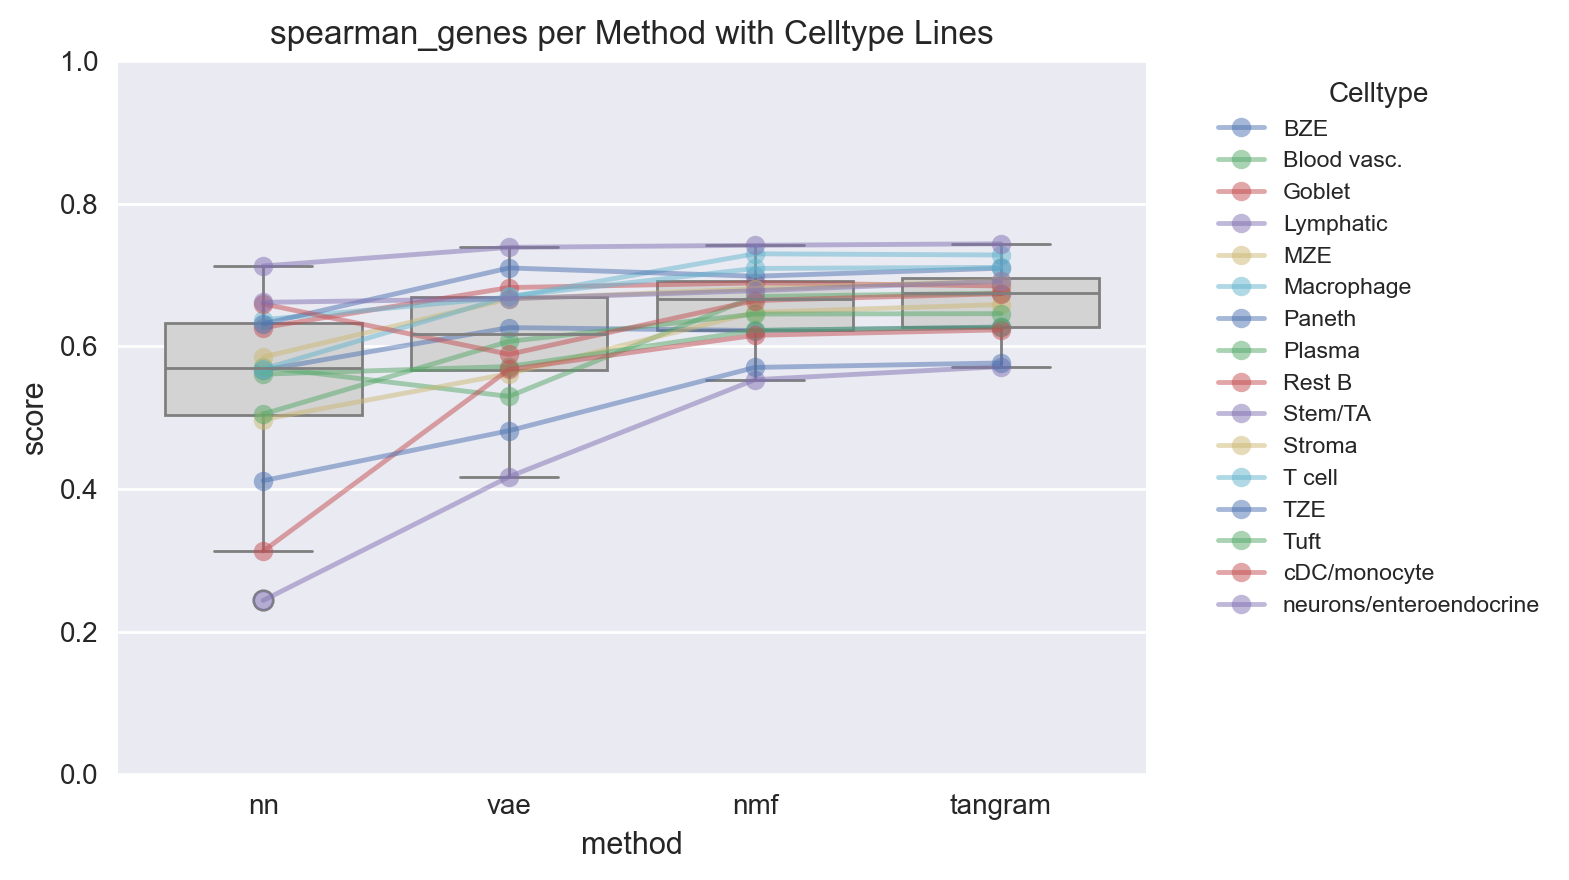

In [20]:
metric_key = "spearman_genes"

metric = metric_registry[metric_key]
df = pd.DataFrame(
    [(celltype, method_name, metric.func(prediction_result.query, prediction_result.predicted)) for celltype, method_name, prediction_result in results],
    columns=["celltype", "method_name", "metric_score"]
).pivot(index="celltype", columns="method_name", values="metric_score")
df = sort_df(df, np.median, axis=0)
print(df)

plt.style.use(plt.style.available[12])
df_reset = df.reset_index().melt(id_vars="celltype", var_name="method", value_name="score")
plt.figure(figsize=(8, 4.5), dpi=200)
sns.boxplot(data=df_reset, x="method", y="score", color="lightgray")
    
for celltype, group in df_reset.groupby("celltype"):
    plt.plot(group["method"], group["score"], marker="o", label=celltype, alpha=0.5)
    
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small", title="Celltype")
plt.title(f"{metric_key} per Method with Celltype Lines")
plt.ylim(metric.plot_range)
plt.tight_layout()
plt.show()

#### Pairplot correlation of performance scores between methods over celltypes
This plot aims to show the correlation of performance scores across methods over celltypes -> high correlation == two methods perform similarily across celltypes

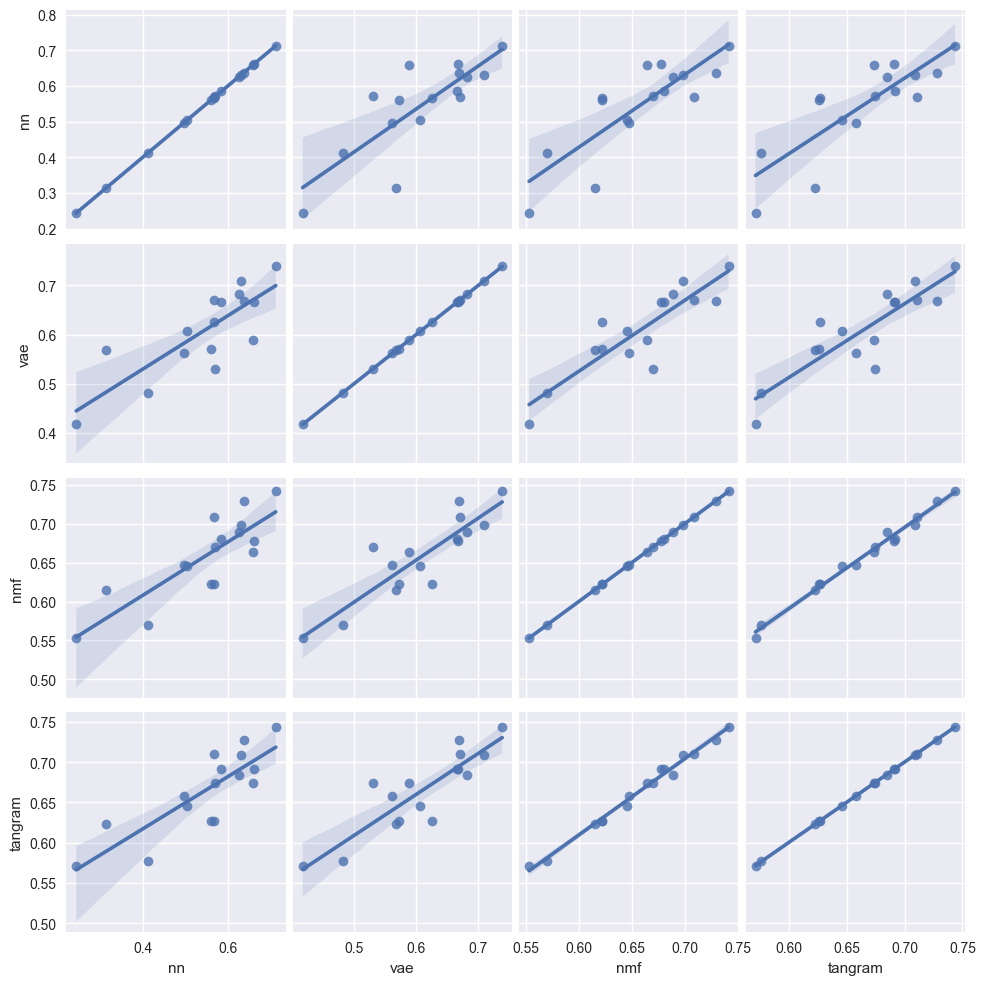

In [14]:
sns.pairplot(df, kind="reg", diag_kind=None)

#### Scatterplot observed v predicted mean counts per gene for each celltype & method
Aims to answer if theres a linear relationship between the predicted counts and observed counts

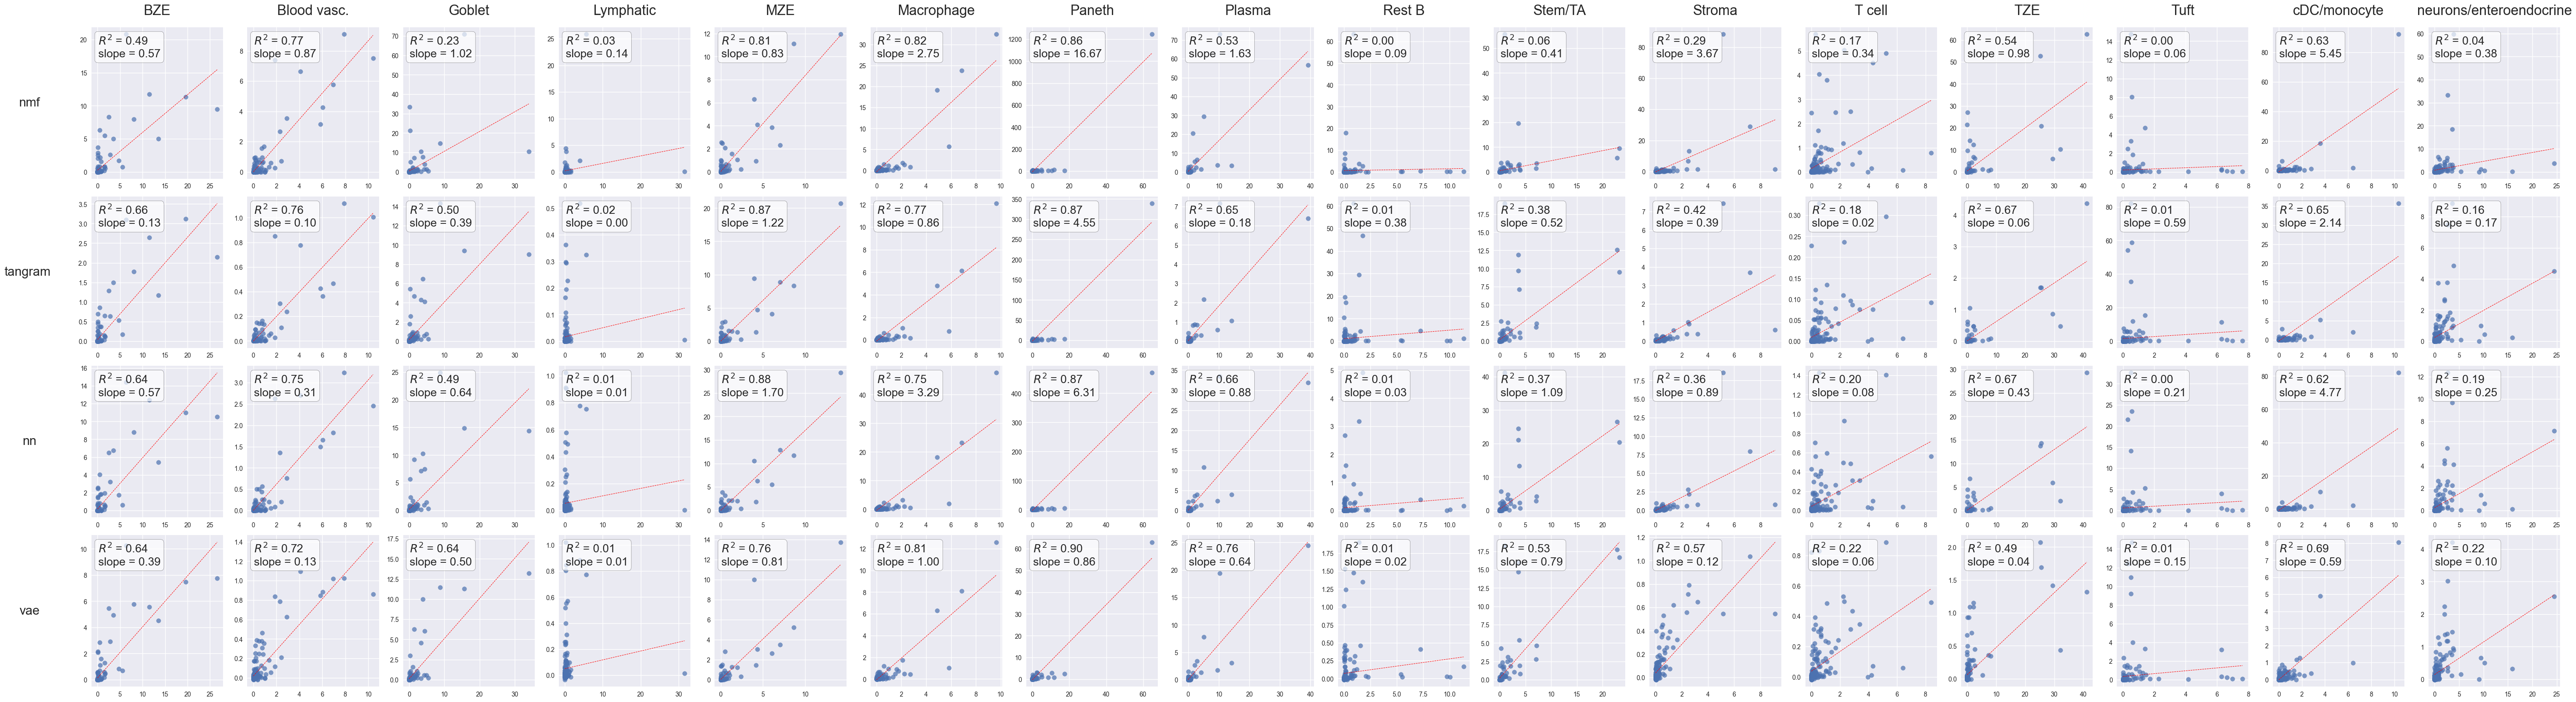

In [15]:
nrows = len(methods)
ncols = len(counts_per_celltype)

combinations = list(itertools.product(methods.items(), counts_per_celltype.items()))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows), squeeze=False)

method_names = list(methods.keys())
celltypes = list(counts_per_celltype.keys())

# Font size settings
label_fontsize = 20
title_fontsize = 22

for idx, ((method_name, method_function), (celltype, (query, reference))) in enumerate(combinations):
    row = idx // ncols
    col = idx % ncols 
    ax = axes[row][col]

    # Get x and y data
    x = query.mean(axis=0)
    y = mean_randomized_cross_feature_prediction(query, reference, method_function, 5, 0).mean(axis=0)

    # Scatter plot
    ax.scatter(x, y, alpha=0.7)

    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    x_vals = np.array([x.min(), x.max()])
    y_vals = intercept + slope * x_vals
    ax.plot(x_vals, y_vals, color='red', linewidth=0.7, linestyle="dashed")

    # Annotate with slope and R²
    ax.text(0.05, 0.95,
            f'$R^2$ = {r_value**2:.2f}\nslope = {slope:.2f}',
            transform=ax.transAxes,
            fontsize=18,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    # Set row labels
    if col == 0:
        ax.set_ylabel(method_name, fontsize=label_fontsize, rotation=0, labelpad=80, va='center')

    # Set column titles
    if row == 0:
        ax.set_title(celltype, fontsize=title_fontsize, pad=20)

plt.tight_layout()
plt.subplots_adjust(left=0.15, top=0.93)
plt.show()

#### Scatterplot prediction scores vs data metrics for each celltype
Aims to answer if we can predict the performance of a method for a celltype based on summary statistics like number of expressed genes

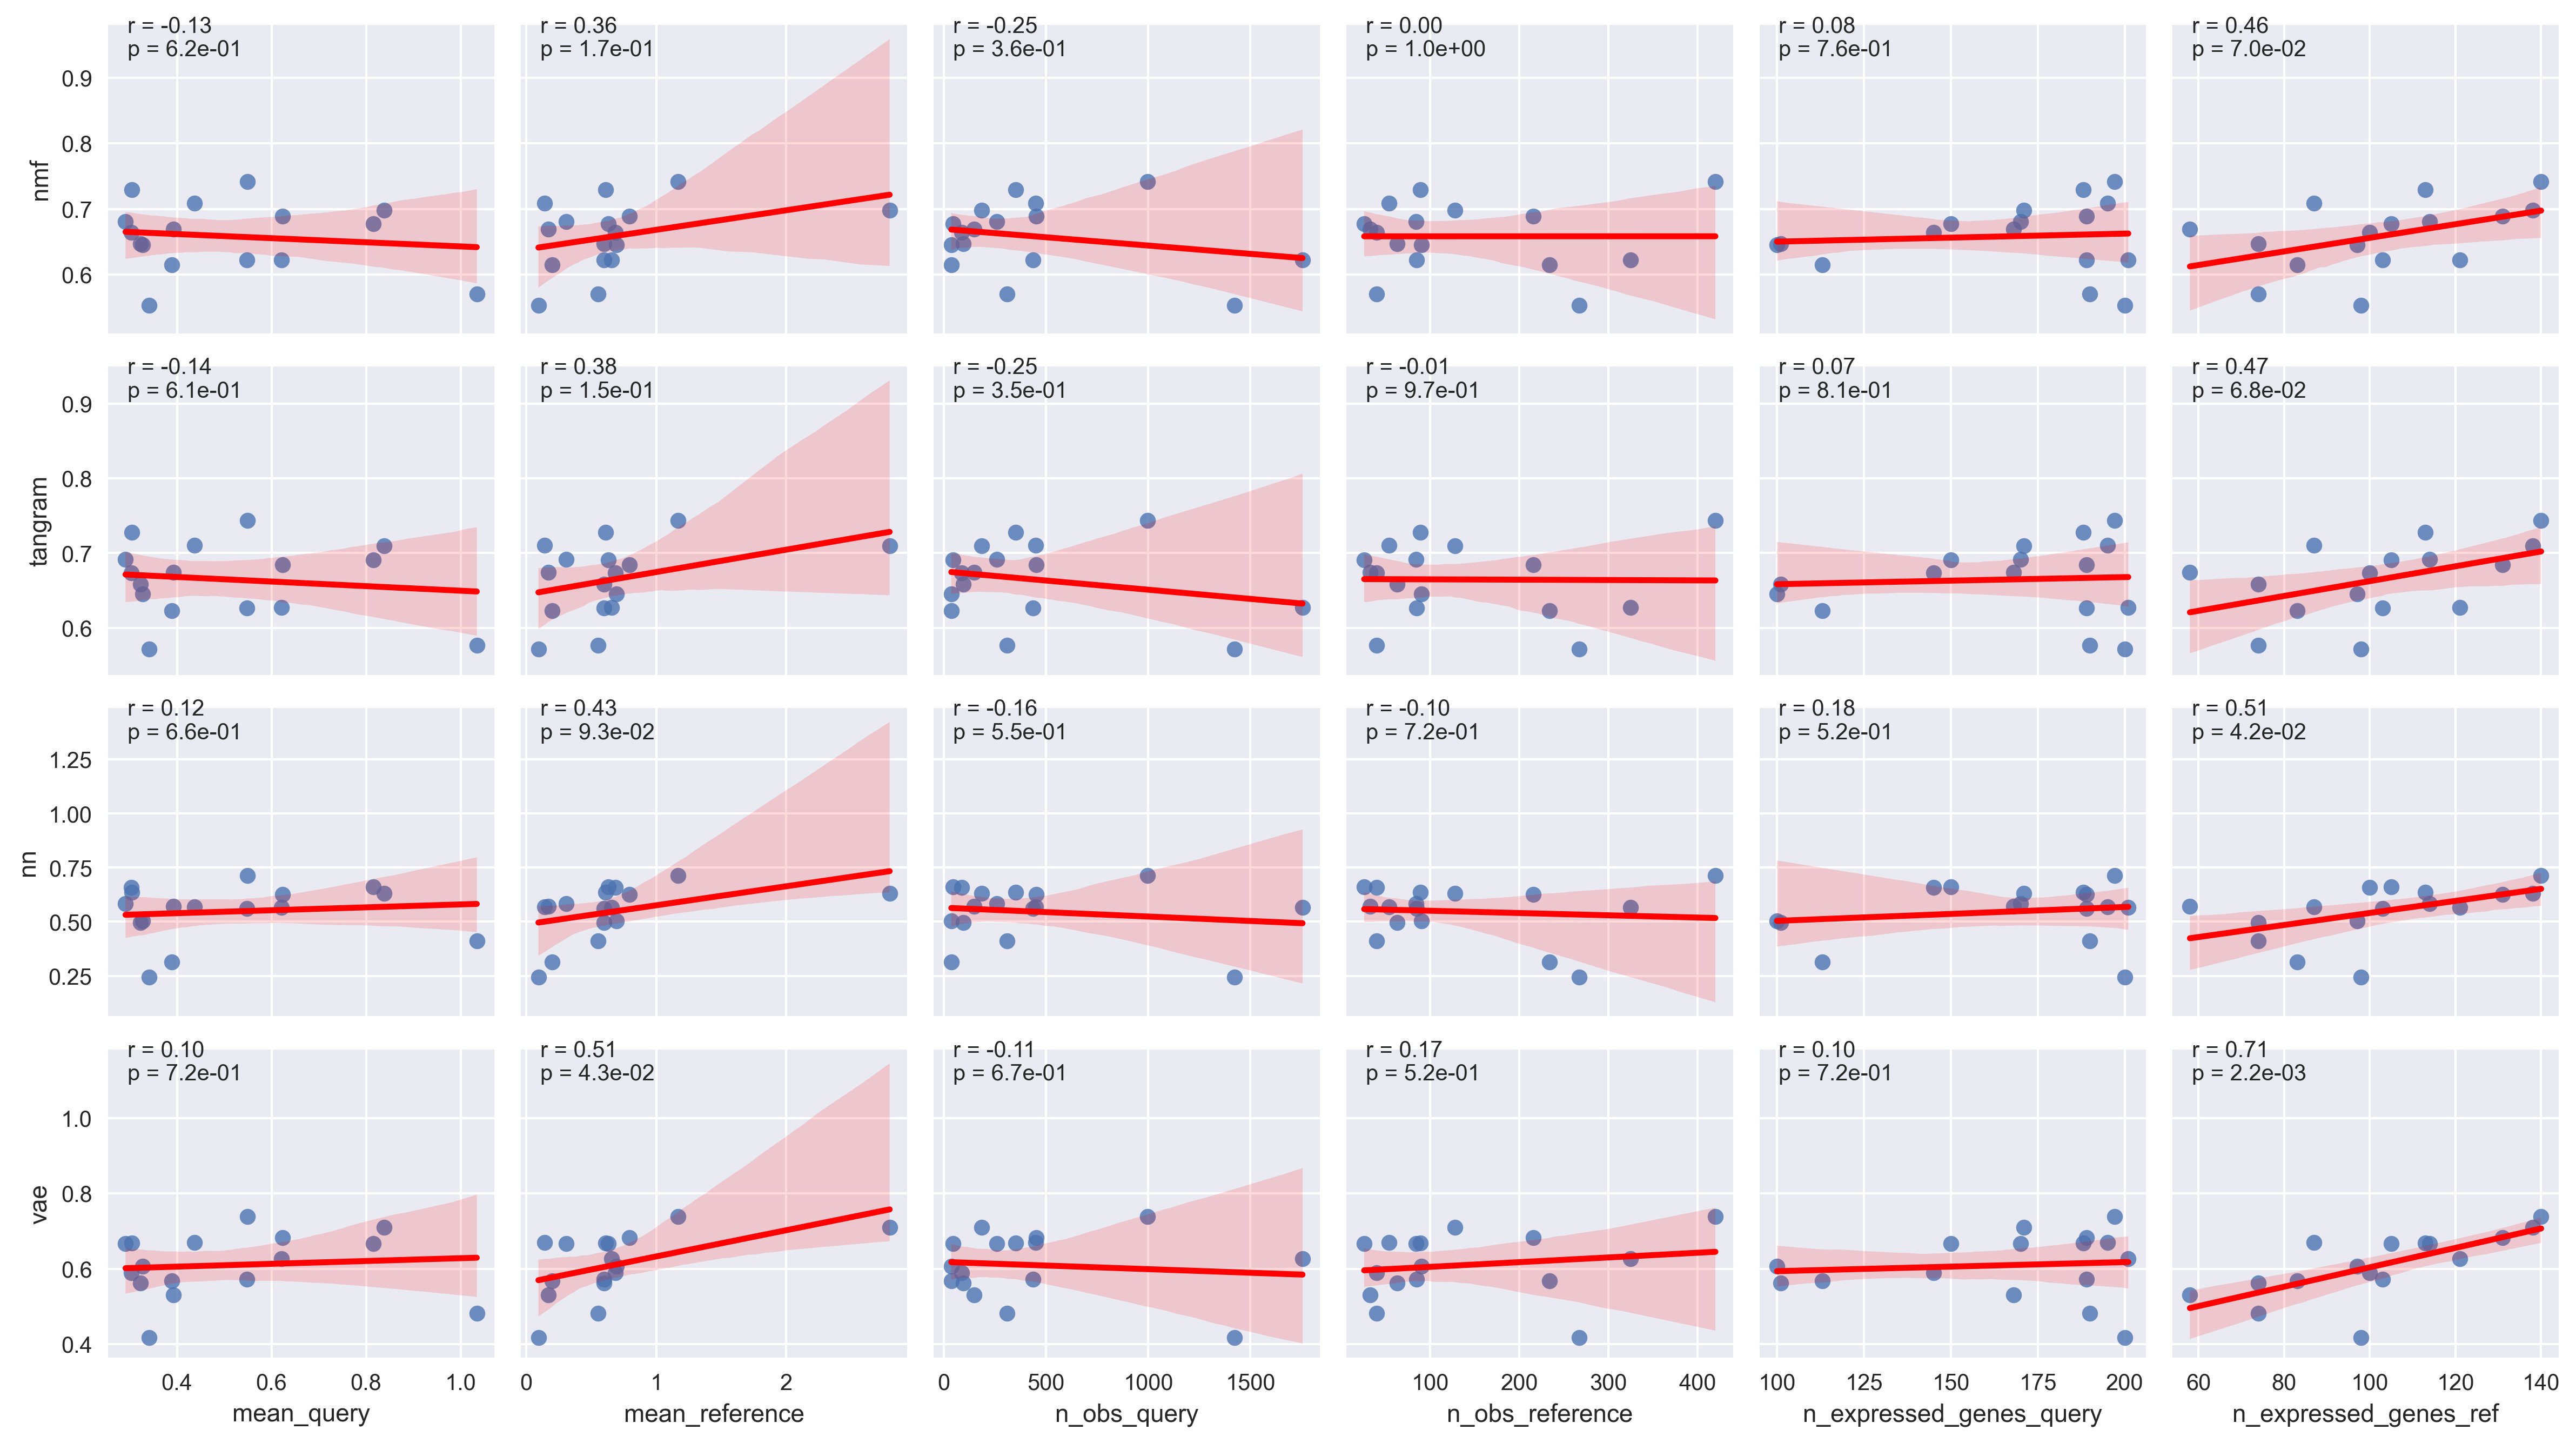

In [16]:
from scipy.stats import pearsonr

functions = [
    ("mean_query", lambda celltype: adata_sp[adata_sp.obs["celltype"] == celltype][:, shared_genes].X.mean().item()),
    ("mean_reference", lambda celltype: adata_sc[adata_sc.obs["celltype"] == celltype][:, shared_genes].X.mean().item()),
    ("n_obs_query", lambda celltype: adata_sp[adata_sp.obs["celltype"] == celltype].n_obs),
    ("n_obs_reference", lambda celltype: adata_sc[adata_sc.obs["celltype"] == celltype].n_obs),
    ("n_expressed_genes_query", lambda celltype: (adata_sp[adata_sp.obs["celltype"] == celltype, shared_genes].X.mean(axis=0) > 0).sum()),
    ("n_expressed_genes_ref", lambda celltype: (adata_sc[adata_sc.obs["celltype"] == celltype, shared_genes].X.mean(axis=0) > 0).sum()),
]
df_metrics = pd.DataFrame(
    [{f_name: f(celltype) for f_name, f in functions} for celltype in shared_celltypes],
    shared_celltypes
)
df_metrics = df.join(df_metrics)

def scatter_with_corr(x, y, **kwargs):
    ax = plt.gca()
    sns.regplot(x=x, y=y, ax=ax, scatter_kws={"s": 50}, line_kws={"color": "red"})
    
    r, p = pearsonr(x, y)
    ax.annotate(f'r = {r:.2f}\np = {p:.1e}', xy=(0.05, 0.9), xycoords=ax.transAxes)

g = sns.PairGrid(
    df_metrics, 
    y_vars=[method_name for method_name, _ in methods.items()], 
    x_vars=[f_name for f_name, _ in functions],
)
g.figure.set_size_inches(16, 9)
g.figure.dpi = 300 

g.map(scatter_with_corr)

plt.tight_layout()
plt.show()